# Robot Current Distribution
## Part 3 — Short-Window Analysis

### Objective
Continue the previous Neon workshop by examining a short interval
of recorded robot current.

The final visualizations will show:
- The current distribution with Q1, median, and Q3.
- A small time-series view of an observed current pulse.

### Scope
Start with a one-minute window and one selected axis.
Preserve original measurements, including zeros.
Use recorded units because the physical unit is not confirmed.

### 1. Inspect Candidate Readings

Read the original CSV locally to select a continuous interval.
This preparation step does not modify the source file or Neon.

Nonzero current does not by itself confirm physical movement.
The selected interval will illustrate this recording, not represent
all robot operating conditions.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

# Locate the project from either its root or the notebooks folder.
relative_source = Path("data/raw/RMBR4-2_export_test.csv")
current_folder = Path.cwd()

project_root = next(
    (
        folder
        for folder in [current_folder, current_folder.parent]
        if (folder / relative_source).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError("The original robot CSV was not found.")

# Load a separate working copy of the original measurements.
original = pd.read_csv(project_root / relative_source)

axis_mapping = {
    f"Axis #{number}": f"Axis{number}"
    for number in range(1, 7)
}

current_data = original[
    ["Time"] + list(axis_mapping)
].rename(
    columns={"Time": "Timestamp", **axis_mapping}
).copy()

# Apply the explicit timestamp-parsing rule established yesterday.
current_data["Timestamp"] = pd.to_datetime(
    current_data["Timestamp"],
    format="ISO8601",
    utc=True,
    errors="raise",
)

if current_data["Timestamp"].isna().any():
    raise ValueError("Missing timestamps found.")

if current_data["Timestamp"].duplicated().any():
    raise ValueError("Duplicate timestamps found.")

current_data = current_data.sort_values(
    "Timestamp"
).reset_index(drop=True)

# Start with Axis1; retain every reading in the working dataset.
selected_axis = "Axis1"

# Use this filtered preview only to locate a candidate interval.
# Zeros will remain included in the actual analysis window.
candidate_readings = current_data.loc[
    current_data[selected_axis].notna()
    & current_data[selected_axis].ne(0),
    [selected_axis, "Timestamp"],
]

if candidate_readings.empty:
    raise ValueError("No nonzero readings found for the selected axis.")

print("Python executable:", sys.executable)
print("Selected axis:", selected_axis)
print("First five nonzero readings — selection preview only:")
display(candidate_readings.head(5))

Python executable: c:\AI\PROG8245\WranglingWorkshop\.venv\Scripts\python.exe
Selected axis: Axis1
First five nonzero readings — selection preview only:


,Axis1,Timestamp
30,0.33876,2022-10-17 12:19:20.136000+00:00
31,7.37465,2022-10-17 12:19:22.005000+00:00
32,0.44300,2022-10-17 12:19:27.952000+00:00
33,1.79806,2022-10-17 12:19:29.911000+00:00
34,4.45606,2022-10-17 12:19:31.969000+00:00


### 2. Preview a One-Minute Window

Inspect the interval from 2022-10-17 12:19:10 UTC up to,
but not including, 12:20:10 UTC.

This window includes the first nonzero Axis1 reading and preceding
observations. It is selected for illustration, not as a representative
sample of the full recording.

Preserve zeros and plot each observed reading as a point.
Connecting lines guide the eye; they are not additional measurements.

This local preview helps select the interval before loading it into Neon.

Selected axis: Axis1
Window start (UTC): 2022-10-17 12:19:10+00:00
Window end (UTC, excluded): 2022-10-17 12:20:10+00:00
Recorded samples: 29
Largest interval between samples: 5.947 seconds


,Axis1,Timestamp
25,0.0,2022-10-17 12:19:10.701000+00:00
26,0.0,2022-10-17 12:19:12.568000+00:00
27,0.0,2022-10-17 12:19:14.427000+00:00
28,0.0,2022-10-17 12:19:16.386000+00:00
29,0.0,2022-10-17 12:19:18.218000+00:00


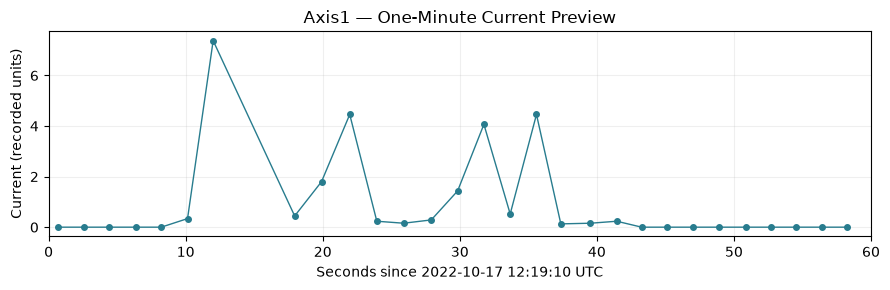

In [2]:
import matplotlib.pyplot as plt

# Define an explicit, reproducible interval: start included, end excluded.
window_start = pd.Timestamp("2022-10-17 12:19:10", tz="UTC")
window_end = window_start + pd.Timedelta(minutes=1)

window_data = current_data.loc[
    current_data["Timestamp"].ge(window_start)
    & current_data["Timestamp"].lt(window_end)
].copy()

if len(window_data) < 2:
    raise ValueError("The selected window has too few observations.")

if window_data[selected_axis].isna().any():
    raise ValueError("The selected axis contains missing measurements.")

# Measure time from the requested window start.
elapsed_seconds = (
    window_data["Timestamp"] - window_start
).dt.total_seconds()

intervals = window_data["Timestamp"].diff().dt.total_seconds()

print("Selected axis:", selected_axis)
print("Window start (UTC):", window_start)
print("Window end (UTC, excluded):", window_end)
print("Recorded samples:", len(window_data))
print(f"Largest interval between samples: {intervals.max():.3f} seconds")

# Show the column under analysis first.
display(window_data[[selected_axis, "Timestamp"]].head(5))

# Preview the actual readings without smoothing or filling gaps.
fig_preview, ax = plt.subplots(figsize=(9, 3))

ax.plot(
    elapsed_seconds,
    window_data[selected_axis],
    marker="o",
    markersize=4,
    linewidth=1,
    color="#287C8E",
)

ax.set_title(f"{selected_axis} — One-Minute Current Preview")
ax.set_xlabel("Seconds since 2022-10-17 12:19:10 UTC")
ax.set_ylabel("Current (recorded units)")
ax.set_xlim(0, 60)
ax.grid(alpha=0.2)

fig_preview.tight_layout()
plt.show()

### 3. Connect to the Existing Neon Database

Reuse the project's local .env configuration to connect to the same
Neon database used in Part 2.

Selected interval:
2022-10-17 12:19:10 UTC to 12:20:10 UTC, excluding the endpoint.

The local preview contains 29 observations and multiple current peaks.
A 5.947-second sampling interval limits the temporal detail around
the first peak.

This cell tests connectivity only. It does not change database records.

In [3]:
from dotenv import dotenv_values
from sqlalchemy import create_engine, text
from sqlalchemy.engine import make_url

# Close any previous pool before rerunning the connection cell.
if "neon_engine" in globals():
    neon_engine.dispose()
    del neon_engine


def connect_to_neon(env_path):
    """Read local configuration and return a tested PostgreSQL engine."""
    if not env_path.is_file():
        raise FileNotFoundError("The project .env file was not found.")

    config = dotenv_values(env_path, interpolate=False)
    uri = config.get("NEON_DATABASE_URL")

    if not uri or not uri.strip():
        raise ValueError("NEON_DATABASE_URL is missing from .env.")

    engine = None

    try:
        url = make_url(uri.strip())

        if url.get_backend_name() != "postgresql":
            raise ValueError("A PostgreSQL connection is required.")

        url = url.set(drivername="postgresql+psycopg2")

        # Preserve the SSL settings provided by Neon.
        if "sslmode" not in url.query:
            url = url.update_query_dict({"sslmode": "require"})

        engine = create_engine(
            url,
            connect_args={"connect_timeout": 15},
            pool_pre_ping=True,
            echo=False,
            hide_parameters=True,
        )

        with engine.connect() as connection:
            result = connection.execute(text("SELECT 1")).scalar_one()

        if result != 1:
            raise RuntimeError("Unexpected connection-test result.")

        return engine

    except Exception:
        if engine is not None:
            engine.dispose()

        # Avoid printing credentials or connection details.
        raise RuntimeError(
            "Neon connection failed. Check .env and network access."
        ) from None


neon_engine = connect_to_neon(project_root / ".env")
print("PASS: connected to the existing Neon PostgreSQL database.")

PASS: connected to the existing Neon PostgreSQL database.


### 4. Load the Selected Minute into Neon

Insert the 29 original measurements from the selected interval into
the existing Robots table.

Reuse the synthetic context established in Part 2:
- Robot_ID: RMBR4-2
- Shop_ID: SH01
- IP_ADDRESS: 192.0.2.10

Existing measurement keys are skipped. No previous records are deleted
or updated.

Read the interval back through a SQL join with Shops and verify that
all six current channels match the original local readings.

In [4]:
from psycopg2.extras import execute_values
from sqlalchemy import text

axis_columns = [f"Axis{i}" for i in range(1, 7)]

# Prepare the original readings with the previously documented context.
upload_rows = [
    (
        "RMBR4-2",
        row.Timestamp.to_pydatetime(),
        *[float(getattr(row, axis)) for axis in axis_columns],
        "192.0.2.10",
        "SH01",
    )
    for row in window_data.itertuples(index=False)
]

insert_sql = """
    INSERT INTO wrangling.robots (
        robot_id, timestamp,
        axis1, axis2, axis3, axis4, axis5, axis6,
        ip_address, shop_id
    )
    VALUES %s
    ON CONFLICT (robot_id, timestamp) DO NOTHING
"""

# Insert the small window in one batch and one transaction.
raw_connection = neon_engine.raw_connection()

try:
    with raw_connection.cursor() as cursor:
        cursor.execute("SET LOCAL statement_timeout = '15s'")
        cursor.execute("SET LOCAL lock_timeout = '5s'")
        execute_values(
            cursor,
            insert_sql,
            upload_rows,
            page_size=len(upload_rows),
        )
        inserted_rows = cursor.rowcount

    raw_connection.commit()

except BaseException:
    raw_connection.rollback()
    raise

finally:
    raw_connection.close()

# Query the same interval from Neon and include its shop context.
window_query = text("""
    SELECT
        r.shop_id AS "Shop_ID",
        s.takt AS "Takt",
        r.robot_id AS "Robot_ID",
        r.timestamp AS "Timestamp",
        r.axis1 AS "Axis1",
        r.axis2 AS "Axis2",
        r.axis3 AS "Axis3",
        r.axis4 AS "Axis4",
        r.axis5 AS "Axis5",
        r.axis6 AS "Axis6"
    FROM wrangling.robots AS r
    LEFT JOIN wrangling.shops AS s
        ON r.shop_id = s.shop_id
    WHERE r.robot_id = :robot_id
      AND r.timestamp >= :window_start
      AND r.timestamp < :window_end
    ORDER BY r.timestamp
""")

with neon_engine.connect() as connection:
    connection.execute(text("SET statement_timeout = '15s'"))
    neon_window = pd.read_sql_query(
        window_query,
        connection,
        params={
            "robot_id": "RMBR4-2",
            "window_start": window_start.to_pydatetime(),
            "window_end": window_end.to_pydatetime(),
        },
    )

neon_window["Timestamp"] = pd.to_datetime(
    neon_window["Timestamp"],
    format="ISO8601",
    utc=True,
    errors="raise",
)

# Confirm that every timestamp and current reading survived unchanged.
comparison_columns = ["Timestamp"] + axis_columns

pd.testing.assert_frame_equal(
    neon_window[comparison_columns].reset_index(drop=True),
    window_data[comparison_columns].reset_index(drop=True),
    check_dtype=False,
    check_exact=True,
)

# Confirm that the joined context matches the agreed exercise.
if (
    not neon_window["Shop_ID"].eq("SH01").all()
    or not neon_window["Takt"].eq(120).all()
):
    raise ValueError("Unexpected shop context in the selected window.")

print(f"New measurements inserted: {inserted_rows}")
print(f"Verified measurements in the selected minute: {len(neon_window)}")
print("PASS: Neon readings match the original window.")

# Show the merge columns and selected channel first.
display(
    neon_window[
        ["Shop_ID", "Takt", selected_axis, "Timestamp", "Robot_ID"]
    ].head(5)
)

New measurements inserted: 0
Verified measurements in the selected minute: 29
PASS: Neon readings match the original window.


,Shop_ID,Takt,Axis1,Timestamp,Robot_ID
0,SH01,120.0,0.0,2022-10-17 12:19:10.701000+00:00,RMBR4-2
1,SH01,120.0,0.0,2022-10-17 12:19:12.568000+00:00,RMBR4-2
2,SH01,120.0,0.0,2022-10-17 12:19:14.427000+00:00,RMBR4-2
3,SH01,120.0,0.0,2022-10-17 12:19:16.386000+00:00,RMBR4-2
4,SH01,120.0,0.0,2022-10-17 12:19:18.218000+00:00,RMBR4-2


### 5. Calculate Quartiles Using a Simple Class

RobotCurrentAnalysis stores a copy of the Neon query result and
provides a method to summarize one selected axis.

- Q1: 25th percentile.
- Median (Q2): 50th percentile.
- Q3: 75th percentile.
- IQR: Q3 minus Q1.
- Range: maximum minus minimum.

Quartiles use pandas' linear interpolation method.
All recorded values, including zeros, remain included.

This introduces a simple OOP structure: an object holds the data,
and a method performs the calculation.

In [5]:
import numpy as np


class RobotCurrentAnalysis:
    """Summarize current readings retrieved from Neon."""

    def __init__(self, data):
        # Keep an independent copy of the queried measurements.
        self.data = data.copy()

    def summarize(self, axis):
        """Return descriptive statistics for one recorded axis."""
        allowed_axes = [f"Axis{i}" for i in range(1, 7)]

        if axis not in allowed_axes:
            raise ValueError("Select an axis from Axis1 to Axis6.")

        values = pd.to_numeric(self.data[axis], errors="raise")

        # Reject invalid readings rather than silently removing them.
        if values.empty or values.isna().any():
            raise ValueError("Current readings must be present and nonmissing.")

        if not np.isfinite(values.to_numpy(dtype=float)).all():
            raise ValueError("Current readings must contain finite values.")

        # Compute quartiles without excluding recorded zeros.
        quartiles = values.quantile(
            [0.25, 0.50, 0.75],
            interpolation="linear",
        )
        q1, median, q3 = quartiles.tolist()

        return pd.DataFrame([{
            "Axis": axis,
            "Q1": q1,
            "Median_Q2": median,
            "Q3": q3,
            "IQR": q3 - q1,
            "Minimum": values.min(),
            "Maximum": values.max(),
            "Range": values.max() - values.min(),
            "SampleCount": len(values),
            "ZeroCount": int(values.eq(0).sum()),
        }])


# Instantiate the class using the data read from Neon.
current_analysis = RobotCurrentAnalysis(neon_window)

# Call its method for the selected axis.
current_summary = current_analysis.summarize(selected_axis)

print("Quartiles for the selected minute — zeros included:")
display(current_summary.round(4))

Quartiles for the selected minute — zeros included:


,Axis,Q1,Median_Q2,Q3,IQR,Minimum,Maximum,Range,SampleCount,ZeroCount
0,Axis1,0.0,0.1303,0.443,0.443,0.0,7.3746,7.3746,29,14


### 6. Gaussian Reference Curve with Quartiles

Draw a normal reference curve using the mean and population standard
deviation of the 29 current readings retrieved from Neon.

Shade the four theoretical quartile regions and mark Q1, Q2, and Q3.
Each region contains 25% of the normal model's probability.

These are model quartiles, not the empirical quartiles calculated
in Section 5. The observed readings are asymmetric and include zeros;
normality is not established.

The normal curve can extend below zero. That portion belongs to the
mathematical model and does not represent observed negative current.

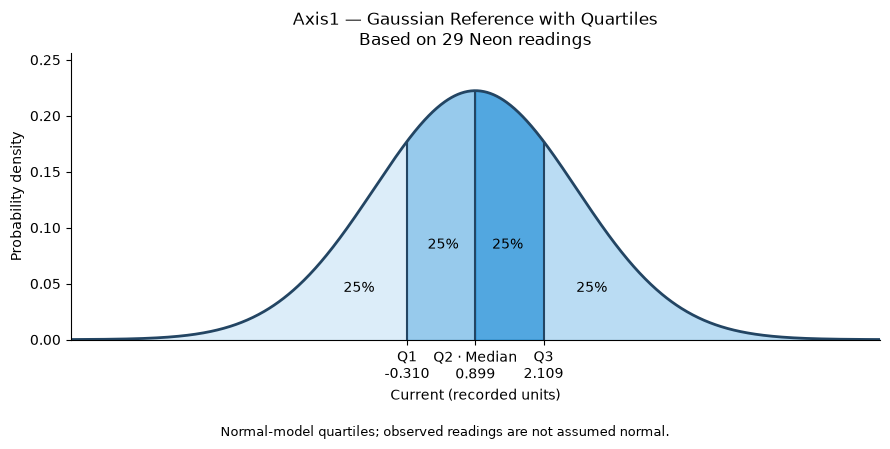

,Quartile,NormalModel,ObservedData
0,Q1,-0.3103,0.0000
1,Q2 (Median),0.8995,0.1303
2,Q3,2.1092,0.4430


Gaussian reference curve and quartile comparison saved.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist

# Use the actual readings retrieved from Neon, including zeros.
values = pd.to_numeric(
    current_analysis.data[selected_axis],
    errors="raise",
).to_numpy(dtype=float)

if len(values) < 2 or not np.isfinite(values).all():
    raise ValueError("At least two finite readings are required.")

# Estimate the parameters of a normal reference model.
# ddof=0 uses the population-standard-deviation convention.
mean_current = float(values.mean())
std_current = float(values.std(ddof=0))

if std_current <= 0:
    raise ValueError("A Gaussian curve requires nonzero variation.")

normal_model = NormalDist(mu=mean_current, sigma=std_current)

# Calculate theoretical quartiles of the normal model.
model_quartiles = [
    normal_model.inv_cdf(probability)
    for probability in [0.25, 0.50, 0.75]
]
q1_model, q2_model, q3_model = model_quartiles

def normal_density(x):
    """Evaluate the normal probability density."""
    return (
        np.exp(-0.5 * ((x - mean_current) / std_current) ** 2)
        / (std_current * np.sqrt(2 * np.pi))
    )

# Display nearly the entire curve without clipping its negative tail.
left = mean_current - 4 * std_current
right = mean_current + 4 * std_current
x = np.linspace(left, right, 1000)

fig_distribution, ax = plt.subplots(figsize=(9, 4.5))

boundaries = [left, q1_model, q2_model, q3_model, right]
colors = ["#D6EAF8", "#85C1E9", "#3498DB", "#AED6F1"]

# Shade each theoretical quartile region.
# The two outer regions continue beyond the displayed axis limits.
for index, color in enumerate(colors):
    region_x = np.linspace(
        boundaries[index], boundaries[index + 1], 200
    )
    ax.fill_between(
        region_x, normal_density(region_x),
        color=color, alpha=0.85,
    )

ax.plot(x, normal_density(x), color="#234563", linewidth=2)

# Mark quartiles from the baseline to the curve.
for label, quartile in zip(
    ["Q1", "Q2 (Median)", "Q3"], model_quartiles
):
    ax.vlines(
        quartile, 0, normal_density(quartile),
        color="#234563", linewidth=1.5,
    )

# Place the four 25% labels within their corresponding regions.
peak_density = normal_density(mean_current)

for probability in [0.125, 0.375, 0.625, 0.875]:
    position = normal_model.inv_cdf(probability)
    ax.text(
        position, normal_density(position) * 0.4,
        "25%", ha="center", va="center",
    )

ax.set_xticks(model_quartiles)
ax.set_xticklabels([
    f"Q1\n{q1_model:.3f}",
    f"Q2 · Median\n{q2_model:.3f}",
    f"Q3\n{q3_model:.3f}",
])

ax.set_title(
    f"{selected_axis} — Gaussian Reference with Quartiles\n"
    f"Based on {len(values)} Neon readings"
)
ax.set_xlabel("Current (recorded units)")
ax.set_ylabel("Probability density")
ax.set_xlim(left, right)
ax.set_ylim(0, peak_density * 1.15)
ax.spines[["top", "right"]].set_visible(False)

fig_distribution.text(
    0.5, 0.02,
    "Normal-model quartiles; observed readings are not assumed normal.",
    ha="center", fontsize=9,
)
fig_distribution.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# Compare model quartiles with the actual sample quartiles.
empirical = current_analysis.summarize(selected_axis).iloc[0]

quartile_comparison = pd.DataFrame({
    "Quartile": ["Q1", "Q2 (Median)", "Q3"],
    "NormalModel": model_quartiles,
    "ObservedData": [
        empirical["Q1"],
        empirical["Median_Q2"],
        empirical["Q3"],
    ],
})

display(quartile_comparison.round(4))

# Save the revised figure and the explicit model/data comparison.
distribution_dir = project_root / "reports" / "current_distribution"
distribution_dir.mkdir(parents=True, exist_ok=True)

fig_distribution.savefig(
    distribution_dir / f"{selected_axis.lower()}_gaussian_quartiles.png",
    dpi=200,
    bbox_inches="tight",
)
quartile_comparison.to_csv(
    distribution_dir / f"{selected_axis.lower()}_quartile_comparison.csv",
    index=False,
)

print("Gaussian reference curve and quartile comparison saved.")

## 7. Inspect the First Current Peak

This close-up shows Axis1 readings retrieved from Neon between
2022-10-17 12:19:18 UTC and 12:19:28 UTC (end excluded).

Dots represent recorded measurements. Connecting lines are visual guides;
they do not represent additional measurements.

The highlighted value is the largest recorded current in this window.
The sampling gaps prevent us from determining the exact pulse shape or duration.
Current is shown in recorded units because the source does not confirm the unit.

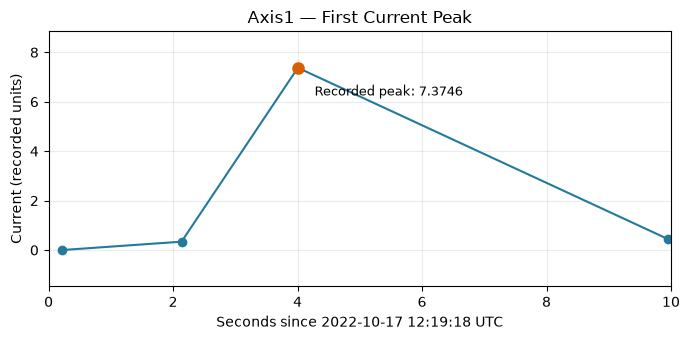

Recorded readings: 4
Largest sampling gap: 5.947 seconds
Recorded peak: 7.37465
Peak timestamp (UTC): 2022-10-17 12:19:22.005000+00:00


,Axis1,Timestamp,ElapsedSeconds
0,0.00000,2022-10-17 12:19:18.218000+00:00,0.218
1,0.33876,2022-10-17 12:19:20.136000+00:00,2.136
2,7.37465,2022-10-17 12:19:22.005000+00:00,4.005
3,0.44300,2022-10-17 12:19:27.952000+00:00,9.952


First-peak figure and readings saved.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Select a ten-second window from the verified Neon readings.
peak_start = pd.Timestamp("2022-10-17 12:19:18", tz="UTC")
peak_end = peak_start + pd.Timedelta(seconds=10)

peak_window = (
    neon_window.loc[
        (neon_window["Timestamp"] >= peak_start)
        & (neon_window["Timestamp"] < peak_end),
        ["Timestamp", selected_axis],
    ]
    .sort_values("Timestamp")
    .reset_index(drop=True)
    .copy()
)

if len(peak_window) < 2:
    raise ValueError("At least two readings are required for the close-up.")

peak_window["ElapsedSeconds"] = (
    peak_window["Timestamp"] - peak_start
).dt.total_seconds()

# Identify the largest recorded value within this window.
peak_row = peak_window.loc[peak_window[selected_axis].idxmax()]
largest_gap = (
    peak_window["Timestamp"].diff().dt.total_seconds().max()
)

fig_peak, ax = plt.subplots(figsize=(7, 3.5))

ax.plot(
    peak_window["ElapsedSeconds"],
    peak_window[selected_axis],
    color="#237a9b",
    marker="o",
    linewidth=1.5,
    label="Recorded readings",
)

ax.scatter(
    peak_row["ElapsedSeconds"],
    peak_row[selected_axis],
    color="#d95f02",
    s=65,
    zorder=3,
)

ax.annotate(
    f"Recorded peak: {peak_row[selected_axis]:.4f}",
    xy=(peak_row["ElapsedSeconds"], peak_row[selected_axis]),
    xytext=(12, -20),
    textcoords="offset points",
    fontsize=9,
)

ax.set_title(f"{selected_axis} — First Current Peak")
ax.set_xlabel("Seconds since 2022-10-17 12:19:18 UTC")
ax.set_ylabel("Current (recorded units)")
ax.set_xlim(0, 10)
ax.margins(y=0.2)
ax.grid(alpha=0.25)
fig_peak.tight_layout()
plt.show()

print(f"Recorded readings: {len(peak_window)}")
print(f"Largest sampling gap: {largest_gap:.3f} seconds")
print(f"Recorded peak: {peak_row[selected_axis]:.5f}")
print(f"Peak timestamp (UTC): {peak_row['Timestamp']}")

display(
    peak_window[
        [selected_axis, "Timestamp", "ElapsedSeconds"]
    ]
)

# Save the figure and its underlying measurements.
peak_report_dir = project_root / "reports" / "current_distribution"
peak_report_dir.mkdir(parents=True, exist_ok=True)

axis_filename = selected_axis.lower()

fig_peak.savefig(
    peak_report_dir / f"{axis_filename}_first_peak.png",
    dpi=160,
    bbox_inches="tight",
)

peak_window.to_csv(
    peak_report_dir / f"{axis_filename}_first_peak.csv",
    index=False,
)

print("First-peak figure and readings saved.")